# Pack segmentation outputs with images and masks
This notebook scans existing segmentation `.npy` files in `C:\Users\kelvin\Downloads\brats_workspace`, loads the corresponding original image and mask volumes, validates shapes, and saves combined `.npz` files.

## 1) Locate Workspace and Scan Existing NPY Files
Set the workspace root and list segmentation `.npy` files.

In [1]:
from pathlib import Path
import re
import numpy as np

# Workspace root containing your segmentation .npy files
WS_ROOT = Path(r"C:\Users\kelvin\Downloads\brats_workspace")

# Where to save the packed outputs
OUT_DIR = WS_ROOT / "packed_npy"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Pattern to extract case id from filename (adjust if needed)
CASE_RE = re.compile(r"(BraTS\d{4}_\d{5})", re.IGNORECASE)

# Find segmentation prediction .npy files
seg_files = sorted(WS_ROOT.rglob("*.npy"))
print(f"Found {len(seg_files)} .npy files under {WS_ROOT}")
seg_files[:10]

Found 67 .npy files under C:\Users\kelvin\Downloads\brats_workspace


[WindowsPath('C:/Users/kelvin/Downloads/brats_workspace/Pred_npy/BraTS2021_00000.npy'),
 WindowsPath('C:/Users/kelvin/Downloads/brats_workspace/Pred_npy/BraTS2021_00002.npy'),
 WindowsPath('C:/Users/kelvin/Downloads/brats_workspace/Pred_npy/BraTS2021_00003.npy'),
 WindowsPath('C:/Users/kelvin/Downloads/brats_workspace/Pred_npy/BraTS2021_00005.npy'),
 WindowsPath('C:/Users/kelvin/Downloads/brats_workspace/Pred_npy/BraTS2021_00006.npy'),
 WindowsPath('C:/Users/kelvin/Downloads/brats_workspace/Pred_npy/BraTS2021_00008.npy'),
 WindowsPath('C:/Users/kelvin/Downloads/brats_workspace/Pred_npy/BraTS2021_00009.npy'),
 WindowsPath('C:/Users/kelvin/Downloads/brats_workspace/Pred_npy/BraTS2021_00011.npy'),
 WindowsPath('C:/Users/kelvin/Downloads/brats_workspace/Pred_npy/BraTS2021_00012.npy'),
 WindowsPath('C:/Users/kelvin/Downloads/brats_workspace/Pred_npy/BraTS2021_00014.npy')]

## 2) Load Original Images and Masks
Set where original images and masks are stored. Supported: `.npy`, `.nii`, `.nii.gz`.

In [6]:
# Adjust these paths to your image/mask sources
IMG_ROOT = Path(r"C:\Users\kelvin\Downloads\brats_web\data")   # contains BraTS2021_00000_flair.nii.gz etc.
MSK_ROOT = Path(r"C:\Users\kelvin\Downloads\brats_web\data")   # contains BraTS2021_00000_gt.nii.gz etc.

# Optional: set filename templates if needed
# Example: IMG_TEMPLATE = "{case_id}_t1.nii.gz"
IMG_TEMPLATE = "{case_id}_flair.nii.gz"
MSK_TEMPLATE = "{case_id}_gt.nii.gz"

# If your images/masks are .npy instead, set templates accordingly
# IMG_TEMPLATE = "{case_id}.npy"
# MSK_TEMPLATE = "{case_id}.npy"

# NIfTI loader (if nibabel is available)
try:
    import nibabel as nib
except Exception:
    nib = None


def load_volume(path: Path) -> np.ndarray:
    if not path.exists():
        raise FileNotFoundError(path)
    if path.suffix == ".npy":
        return np.load(path)
    if path.suffixes[-2:] == [".nii", ".gz"] or path.suffix == ".nii":
        if nib is None:
            raise RuntimeError("nibabel is required to load NIfTI files")
        return nib.load(str(path)).get_fdata().astype(np.float32)
    raise ValueError(f"Unsupported file type: {path}")


def find_case_id(p: Path) -> str | None:
    m = CASE_RE.search(p.name)
    return m.group(1) if m else None

## 3) Validate Shape and Alignment
Check that image, mask, and prediction arrays match. Mismatches are logged and skipped.

In [7]:
from collections import defaultdict

issues = []
records = []

for seg_path in seg_files:
    case_id = find_case_id(seg_path)
    if not case_id:
        issues.append((seg_path, "NO_CASE_ID"))
        continue

    # Build image/mask paths
    img_path = IMG_ROOT / IMG_TEMPLATE.format(case_id=case_id)
    msk_path = MSK_ROOT / MSK_TEMPLATE.format(case_id=case_id)

    try:
        pred = np.load(seg_path)
        img = load_volume(img_path)
        msk = load_volume(msk_path)
    except Exception as e:
        issues.append((seg_path, f"LOAD_FAIL: {e}"))
        continue

    if img.shape != pred.shape or msk.shape != pred.shape:
        issues.append((seg_path, f"SHAPE_MISMATCH img={img.shape} msk={msk.shape} pred={pred.shape}"))
        continue

    records.append({
        "case_id": case_id,
        "seg_path": seg_path,
        "img_path": img_path,
        "msk_path": msk_path,
        "shape": pred.shape,
    })

print(f"Ready: {len(records)} cases")
print(f"Issues: {len(issues)} cases")
issues[:5]

Ready: 67 cases
Issues: 0 cases


[]

## 4) Pack Image–Mask–Prediction Triplets
Build a structured bundle for each case and write to `.npz`.

In [8]:
packed_paths = []

for rec in records:
    case_id = rec["case_id"]
    seg_path = rec["seg_path"]
    img_path = rec["img_path"]
    msk_path = rec["msk_path"]

    pred = np.load(seg_path)
    img = load_volume(img_path)
    msk = load_volume(msk_path)

    out_path = OUT_DIR / f"{case_id}.npz"
    np.savez_compressed(
        out_path,
        image=img,
        mask=msk,
        prediction=pred,
        case_id=case_id,
        src_pred=str(seg_path),
        src_img=str(img_path),
        src_mask=str(msk_path),
    )
    packed_paths.append(out_path)

print(f"Saved {len(packed_paths)} files to {OUT_DIR}")
packed_paths[:5]

Saved 67 files to C:\Users\kelvin\Downloads\brats_workspace\packed_npy


[WindowsPath('C:/Users/kelvin/Downloads/brats_workspace/packed_npy/BraTS2021_00000.npz'),
 WindowsPath('C:/Users/kelvin/Downloads/brats_workspace/packed_npy/BraTS2021_00002.npz'),
 WindowsPath('C:/Users/kelvin/Downloads/brats_workspace/packed_npy/BraTS2021_00003.npz'),
 WindowsPath('C:/Users/kelvin/Downloads/brats_workspace/packed_npy/BraTS2021_00005.npz'),
 WindowsPath('C:/Users/kelvin/Downloads/brats_workspace/packed_npy/BraTS2021_00006.npz')]

## 5) Save Updated NPY Files
Files are saved as compressed `.npz` with keys: `image`, `mask`, `prediction`.

## 6) Quick Sanity Check via Sample Visualization
Overlay one slice to verify alignment.

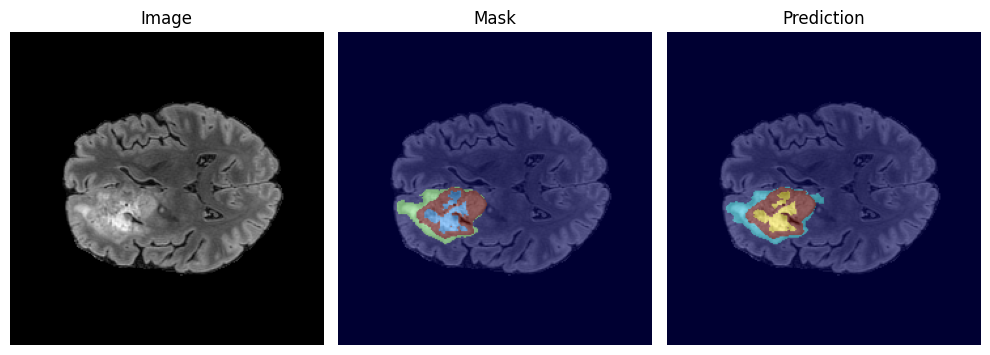

In [9]:
import matplotlib.pyplot as plt

if packed_paths:
    sample = np.load(packed_paths[0])
    img = sample["image"]
    msk = sample["mask"]
    pred = sample["prediction"]

    z = img.shape[2] // 2

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 3, 1)
    plt.title("Image")
    plt.imshow(img[:, :, z], cmap="gray")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Mask")
    plt.imshow(img[:, :, z], cmap="gray")
    plt.imshow(msk[:, :, z], cmap="jet", alpha=0.4)
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Prediction")
    plt.imshow(img[:, :, z], cmap="gray")
    plt.imshow(pred[:, :, z], cmap="jet", alpha=0.4)
    plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No packed files found to visualize.")